In [19]:
import os

data_folder = "../data"
mimic_folder = None

if os.path.exists(data_folder):
    for name in os.listdir(data_folder):
        if "mimic" in name.lower():
            mimic_folder = os.path.join(data_folder, name)
            break

if mimic_folder and os.path.exists(mimic_folder):
    for dirname, _, filenames in os.walk(mimic_folder):
        print("Directory:", dirname)
        for filename in filenames:
            print(os.path.join(dirname, filename))

Directory: ../data\mimic-iii-clinical-database-demo-1.4
../data\mimic-iii-clinical-database-demo-1.4\ADMISSIONS.csv
../data\mimic-iii-clinical-database-demo-1.4\CALLOUT.csv
../data\mimic-iii-clinical-database-demo-1.4\CAREGIVERS.csv
../data\mimic-iii-clinical-database-demo-1.4\CHARTEVENTS.csv
../data\mimic-iii-clinical-database-demo-1.4\CPTEVENTS.csv
../data\mimic-iii-clinical-database-demo-1.4\DATETIMEEVENTS.csv
../data\mimic-iii-clinical-database-demo-1.4\DIAGNOSES_ICD.csv
../data\mimic-iii-clinical-database-demo-1.4\DRGCODES.csv
../data\mimic-iii-clinical-database-demo-1.4\D_CPT.csv
../data\mimic-iii-clinical-database-demo-1.4\D_ICD_DIAGNOSES.csv
../data\mimic-iii-clinical-database-demo-1.4\D_ICD_PROCEDURES.csv
../data\mimic-iii-clinical-database-demo-1.4\D_ITEMS.csv
../data\mimic-iii-clinical-database-demo-1.4\D_LABITEMS.csv
../data\mimic-iii-clinical-database-demo-1.4\ICUSTAYS.csv
../data\mimic-iii-clinical-database-demo-1.4\INPUTEVENTS_CV.csv
../data\mimic-iii-clinical-database-d

In [20]:
# Exploratory Data Analysis (EDA) for MIMIC-III Key Files
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pathlib
import warnings
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

data_dir = pathlib.Path("../data/mimic-iii-clinical-database-demo-1.4/")

file_paths = {
    'admissions': data_dir / 'ADMISSIONS.csv',
    'patients': data_dir / 'PATIENTS.csv',
    'icustays': data_dir / 'ICUSTAYS.csv',
    'diagnoses': data_dir / 'DIAGNOSES_ICD.csv',
    'procedures': data_dir / 'PROCEDURES_ICD.csv',
    'outputevents': data_dir / 'OUTPUTEVENTS.csv',
    'inputevents_mv': data_dir / 'INPUTEVENTS_MV.csv',
    'inputevents_cv': data_dir / 'INPUTEVENTS_CV.csv',
    'labevents': data_dir / 'LABEVENTS.csv',
    'chartevents': data_dir / 'CHARTEVENTS.csv',
    "d_items": data_dir / 'D_ITEMS.csv',
    "d_labitems": data_dir / 'D_LABITEMS.csv',
    "prescriptions": data_dir / 'PRESCRIPTIONS.csv',
    "procedureevents_mv": data_dir / 'PROCEDUREEVENTS_MV.csv',
    'transfers': data_dir / 'TRANSFERS.csv'
}

def load_csv(file_path, chunksize=None):
    if chunksize:
        return pd.concat(pd.read_csv(file_path, chunksize=chunksize, low_memory=False))
    else:
        return pd.read_csv(file_path, low_memory=False)

admissions = load_csv(file_paths['admissions'])
patients = load_csv(file_paths['patients'])
icustays = load_csv(file_paths['icustays'])
diagnoses = load_csv(file_paths['diagnoses'])
procedures = load_csv(file_paths['procedures'])
outputevents = load_csv(file_paths['outputevents'])
inputevents_mv = load_csv(file_paths['inputevents_mv'])
inputevents_cv = load_csv(file_paths['inputevents_cv'])
labevents = load_csv(file_paths['labevents'], chunksize=100000)
chartevents = load_csv(file_paths['chartevents'], chunksize=100000)
d_items = load_csv(file_paths['d_items'])
d_labitems = load_csv(file_paths['d_labitems'])
prescriptions = load_csv(file_paths['prescriptions'], chunksize=100000)
procedureevents_mv = load_csv(file_paths['procedureevents_mv'], chunksize=100000)

print("All key files loaded successfully.")

All key files loaded successfully.


In [21]:
def basic_eda(df, name):
    """Efficient EDA function with better output handling"""
    print(f"\n--- EDA for {name} ---")
    print(f"Shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")
    print("\nHead:")
    print(df.head())
    print("\nDescribe:")
    print(df.describe(include='all'))
    print("\nData Types:")
    print(df.dtypes)
    print("\nMissing Values:")
    print(df.isnull().sum())
    print("\nMissing Percentage:")
    print((df.isnull().sum() / len(df) * 100).round(2))

# Execute with all datasets
basic_eda(admissions, 'ADMISSIONS')
basic_eda(patients, 'PATIENTS')
basic_eda(icustays, 'ICUSTAYS')
basic_eda(diagnoses, 'DIAGNOSES_ICD')
basic_eda(procedures, 'PROCEDURES_ICD')
basic_eda(outputevents, 'OUTPUTEVENTS')
basic_eda(inputevents_mv, 'INPUTEVENTS_MV')
basic_eda(inputevents_cv, 'INPUTEVENTS_CV')
basic_eda(d_items, 'D_ITEMS')
basic_eda(d_labitems, 'D_LABITEMS')

# For large datasets, use a sample for EDA
labevents_sample = pd.read_csv(file_paths['labevents'], nrows=10000, low_memory=False)
chartevents_sample = pd.read_csv(file_paths['chartevents'], nrows=10000, low_memory=False)
basic_eda(labevents_sample, 'LABEVENTS (Sample)')
basic_eda(chartevents_sample, 'CHARTEVENTS (Sample)')

prescriptions_sample = pd.read_csv(file_paths['prescriptions'], nrows=10000, low_memory=False)
procedureevents_mv_sample = pd.read_csv(file_paths['procedureevents_mv'], nrows=10000, low_memory=False)
basic_eda(prescriptions_sample, 'PRESCRIPTIONS (Sample)')
basic_eda(procedureevents_mv_sample, 'PROCEDUREEVENTS_MV (Sample)')


--- EDA for ADMISSIONS ---
Shape: (129, 19)
Columns: ['row_id', 'subject_id', 'hadm_id', 'admittime', 'dischtime', 'deathtime', 'admission_type', 'admission_location', 'discharge_location', 'insurance', 'language', 'religion', 'marital_status', 'ethnicity', 'edregtime', 'edouttime', 'diagnosis', 'hospital_expire_flag', 'has_chartevents_data']

Head:
   row_id  subject_id  hadm_id            admittime            dischtime  \
0   12258       10006   142345  2164-10-23 21:09:00  2164-11-01 17:15:00   
1   12263       10011   105331  2126-08-14 22:32:00  2126-08-28 18:59:00   
2   12265       10013   165520  2125-10-04 23:36:00  2125-10-07 15:13:00   
3   12269       10017   199207  2149-05-26 17:19:00  2149-06-03 18:42:00   
4   12270       10019   177759  2163-05-14 20:43:00  2163-05-15 12:00:00   

             deathtime admission_type         admission_location  \
0                  NaN      EMERGENCY       EMERGENCY ROOM ADMIT   
1  2126-08-28 18:59:00      EMERGENCY  TRANSFER FROM H

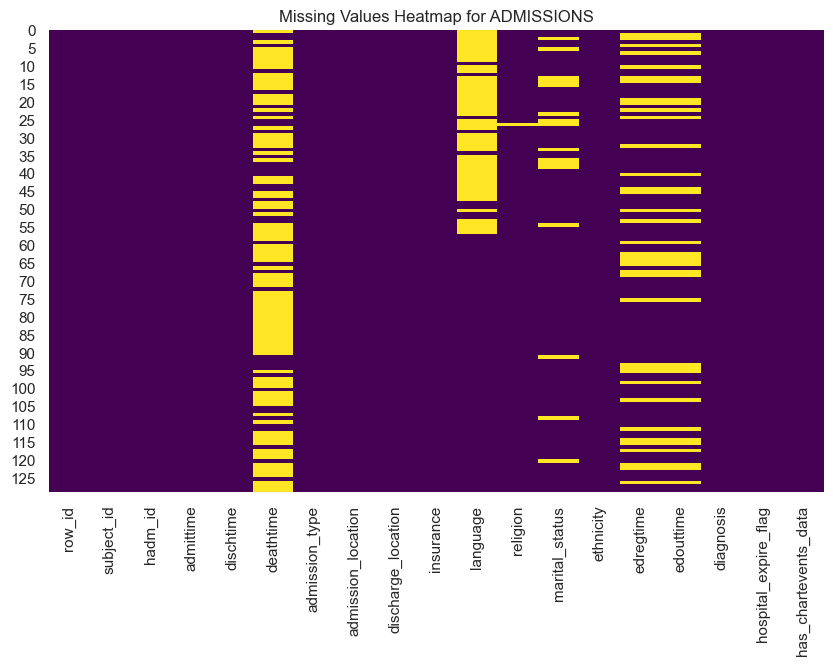

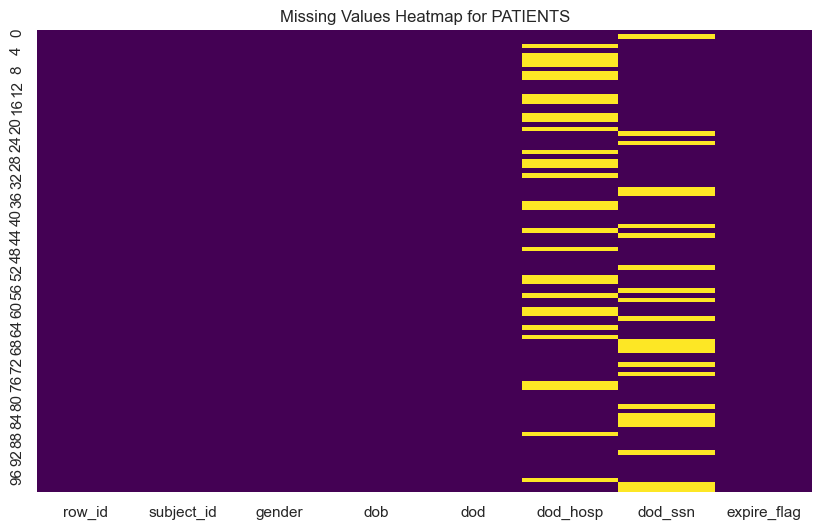

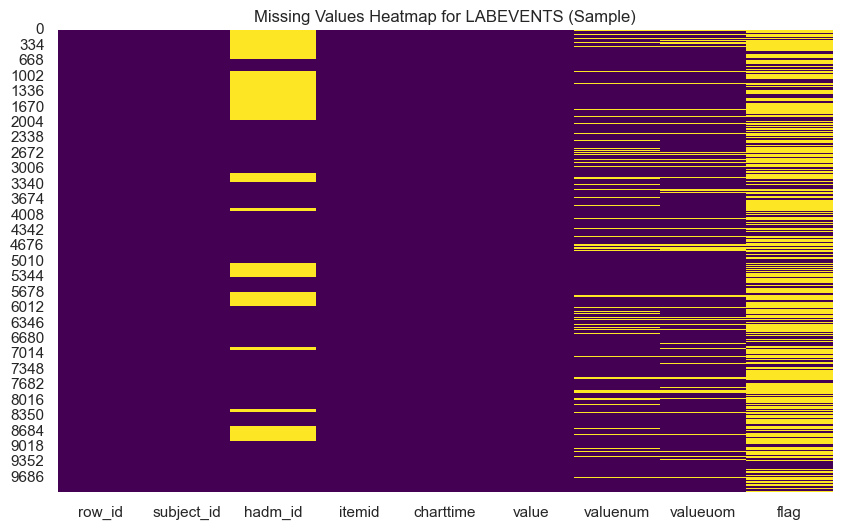

In [22]:
def plot_missing_values(df, name):
    plt.figure(figsize=(10, 6))
    sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
    plt.title(f"Missing Values Heatmap for {name}")
    plt.show()

plot_missing_values(admissions, 'ADMISSIONS')
plot_missing_values(patients, 'PATIENTS')

plot_missing_values(labevents_sample, 'LABEVENTS (Sample)')


INFO:__main__:Calculating ages for all admissions...
ERROR:__main__:Error calculating age for SUBJECT_ID=10026: Result is too large for pandas.Timedelta. Convert inputs to datetime.datetime with 'Timestamp.to_pydatetime()' before subtracting.
ERROR:__main__:Error calculating age for SUBJECT_ID=10036: Result is too large for pandas.Timedelta. Convert inputs to datetime.datetime with 'Timestamp.to_pydatetime()' before subtracting.
ERROR:__main__:Error calculating age for SUBJECT_ID=10094: Result is too large for pandas.Timedelta. Convert inputs to datetime.datetime with 'Timestamp.to_pydatetime()' before subtracting.
ERROR:__main__:Error calculating age for SUBJECT_ID=10094: Result is too large for pandas.Timedelta. Convert inputs to datetime.datetime with 'Timestamp.to_pydatetime()' before subtracting.
ERROR:__main__:Error calculating age for SUBJECT_ID=40655: Result is too large for pandas.Timedelta. Convert inputs to datetime.datetime with 'Timestamp.to_pydatetime()' before subtractin

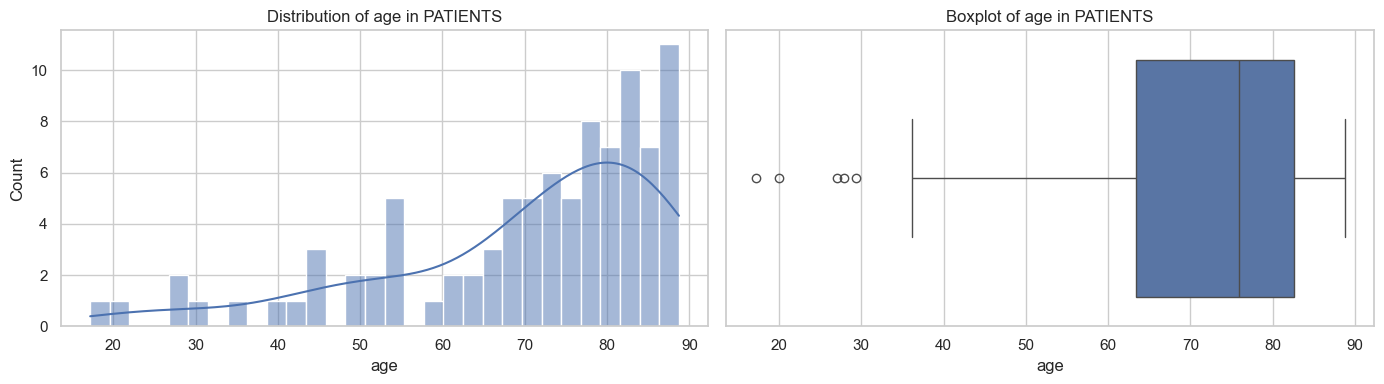

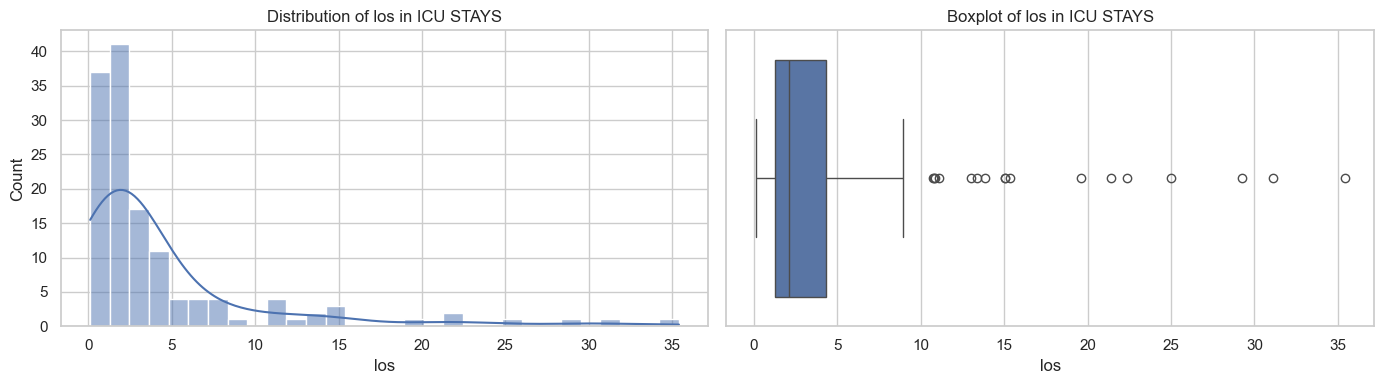

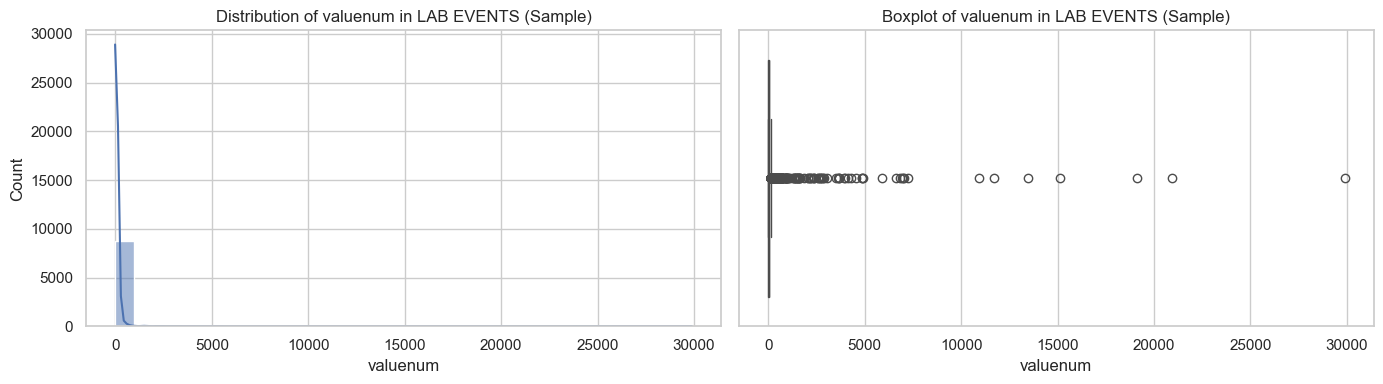

INFO:__main__:Analyzing categorical variables...


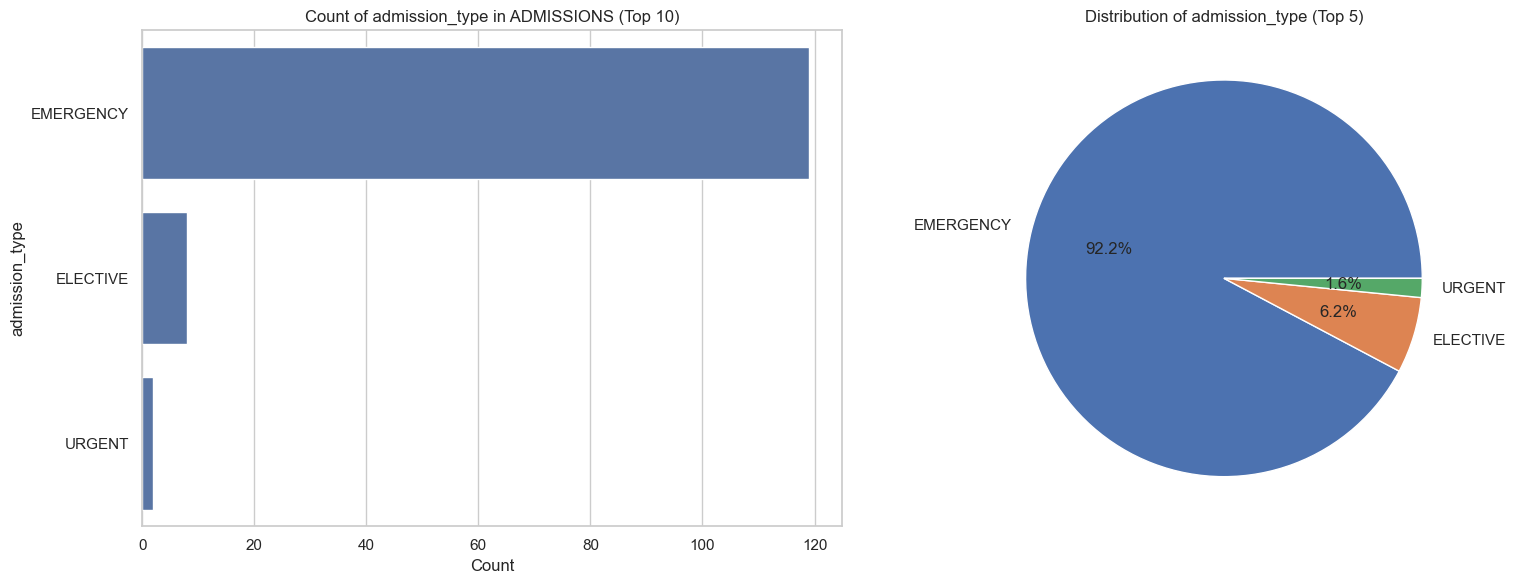

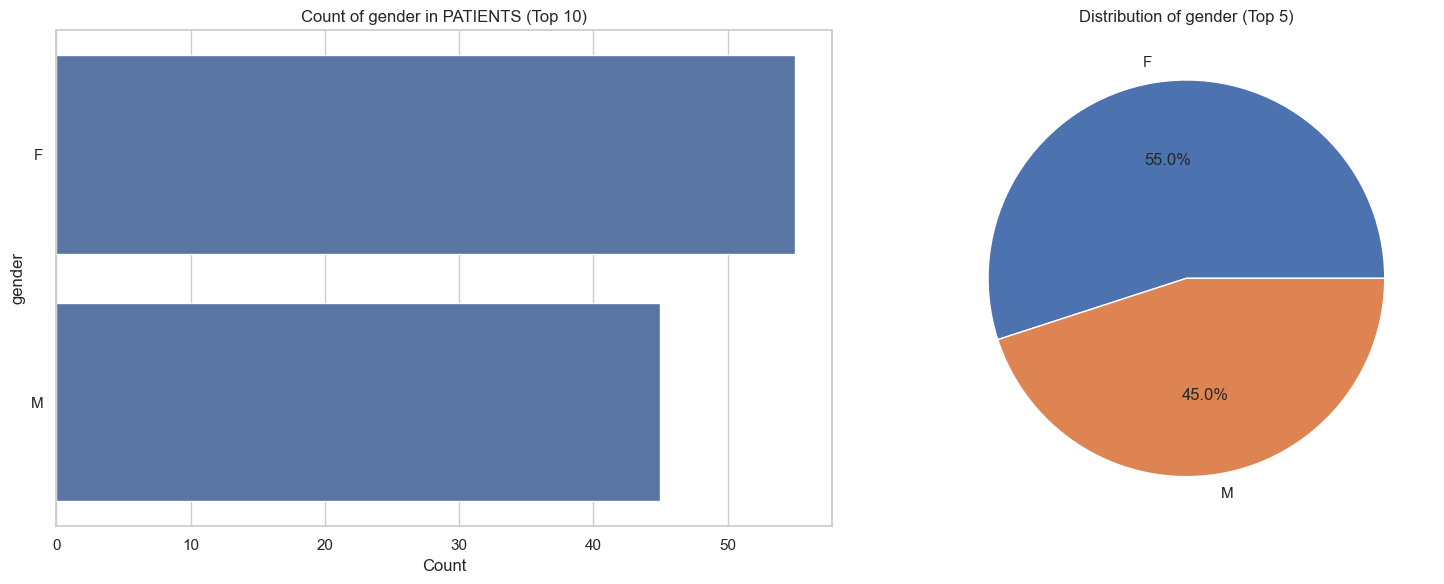

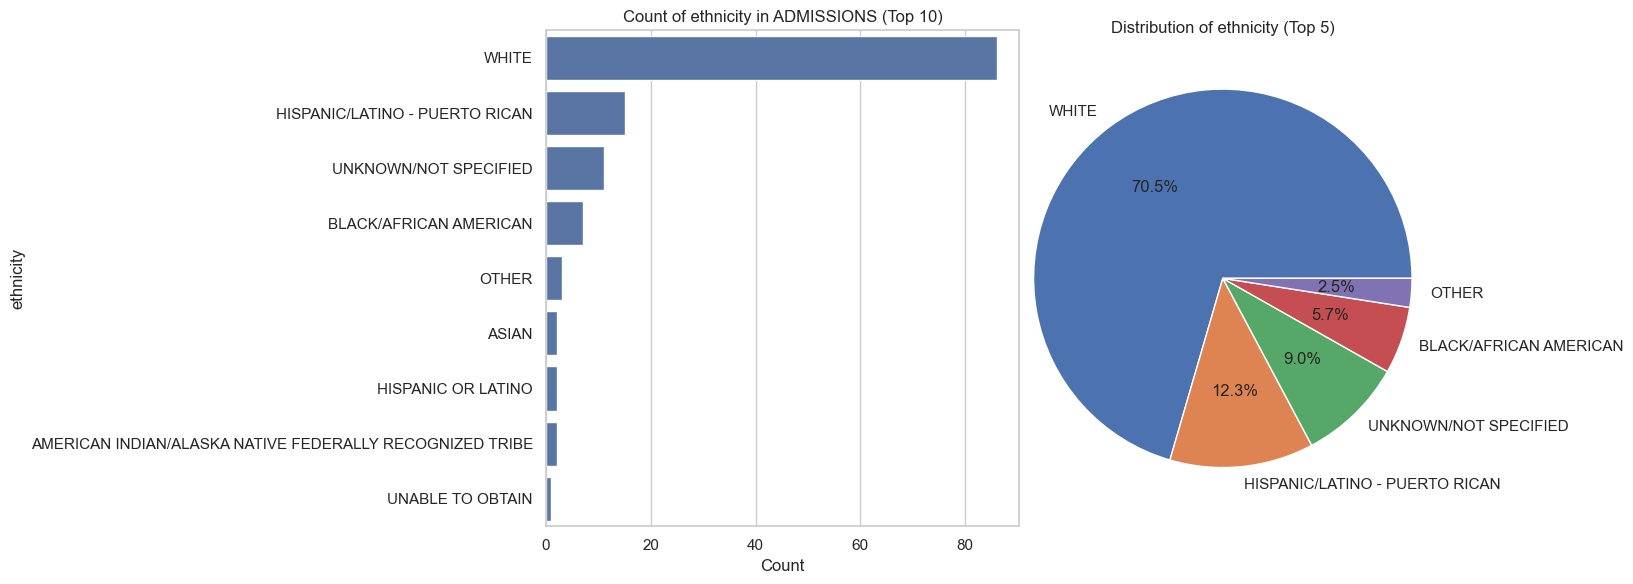

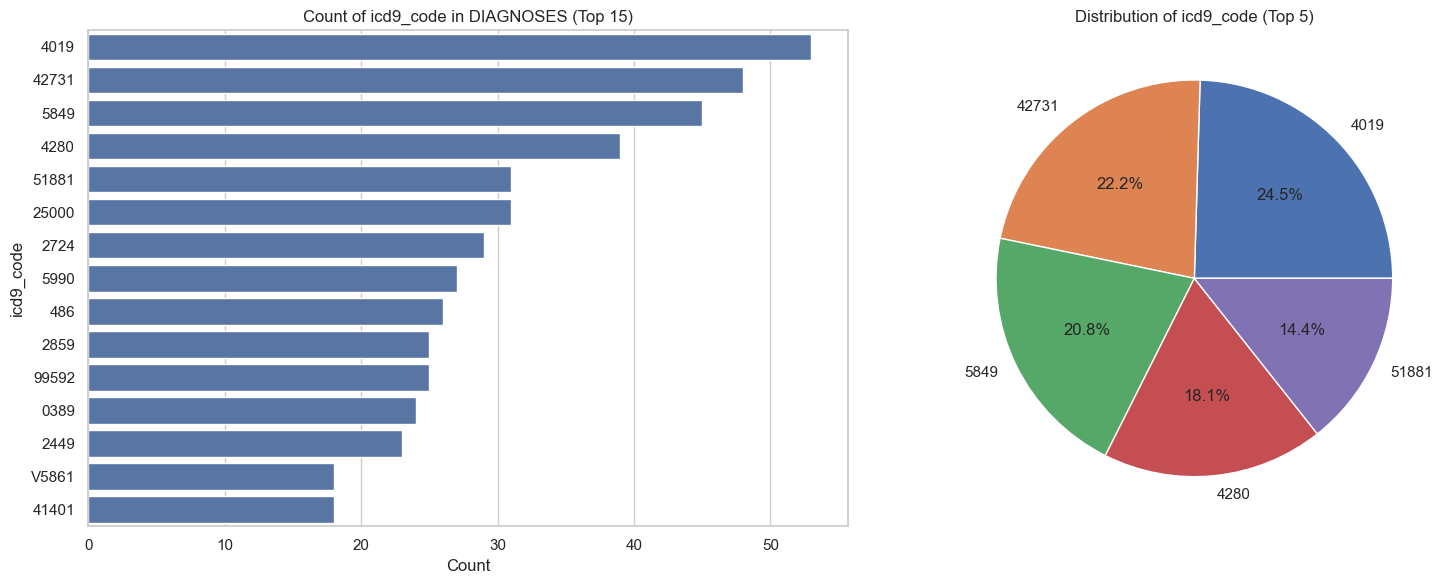

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


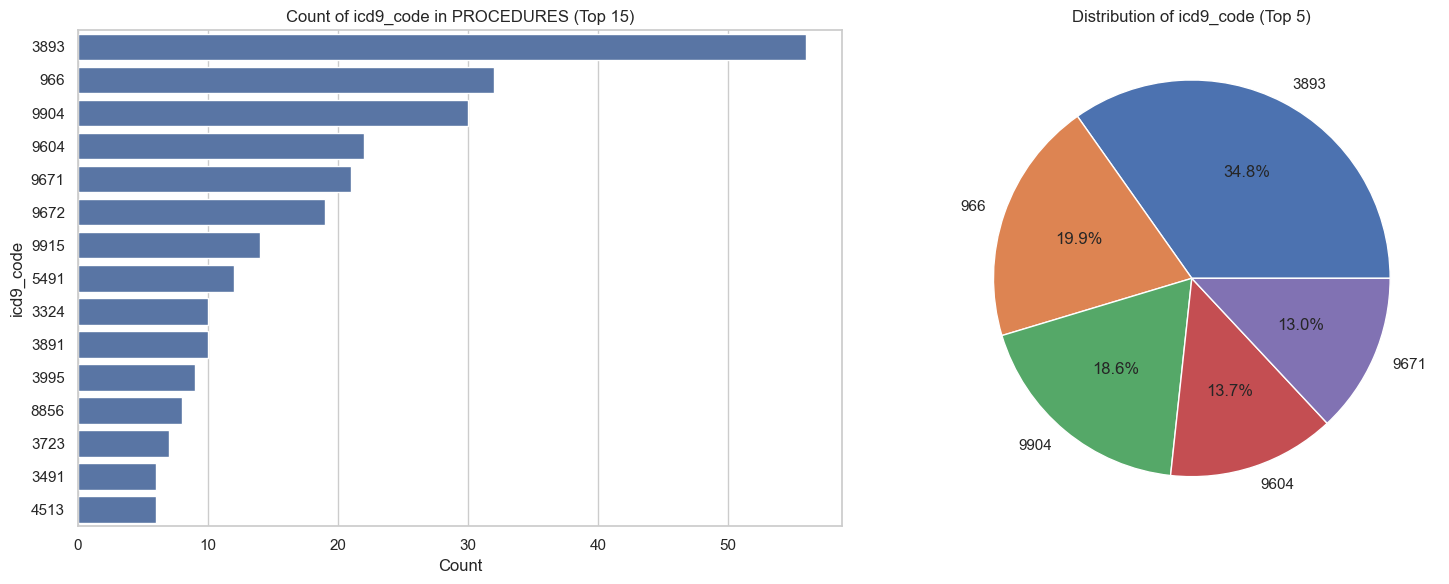

INFO:__main__:Basic EDA Completed!
INFO:__main__:Starting Comprehensive MIMIC-III Analysis


1. GENDER DIFFERENCES IN MORTALITY

Mortality by Gender:
        count  deaths  mortality_rate
gender                               
F          59      21        0.355932
M          70      19        0.271429


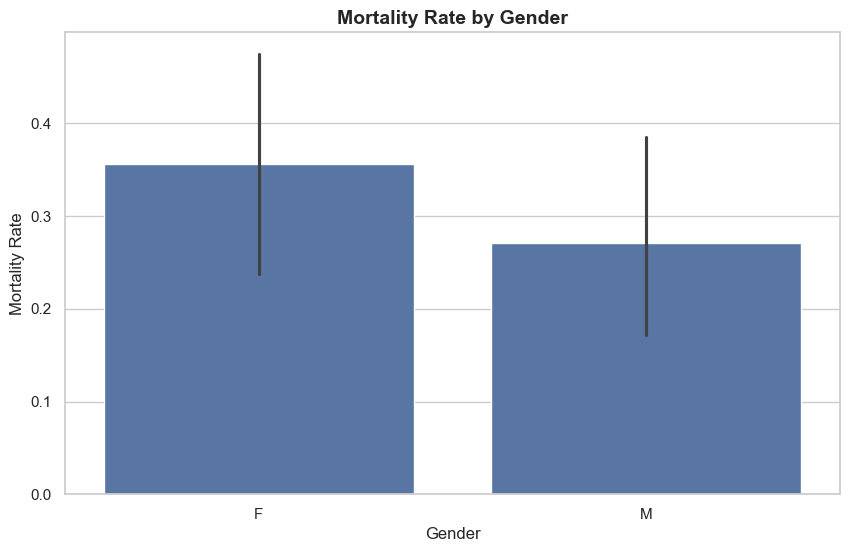


2. ETHNICITY AND OUTCOMES

Outcomes by Ethnicity:
                               hospital_expire_flag                age
                                              count sum   mean    mean
ethnicity_grouped                                                     
ASIAN                                             2   1  0.500  69.688
BLACK/AFRICAN AMERICAN                            7   2  0.286  66.097
HISPANIC OR LATINO                                2   1  0.500  77.413
HISPANIC/LATINO - PUERTO RICAN                   15   0  0.000  64.553
OTHER                                             6   4  0.667  49.627
UNKNOWN/NOT SPECIFIED                            11   5  0.455  61.533
WHITE                                            86  27  0.314  71.920


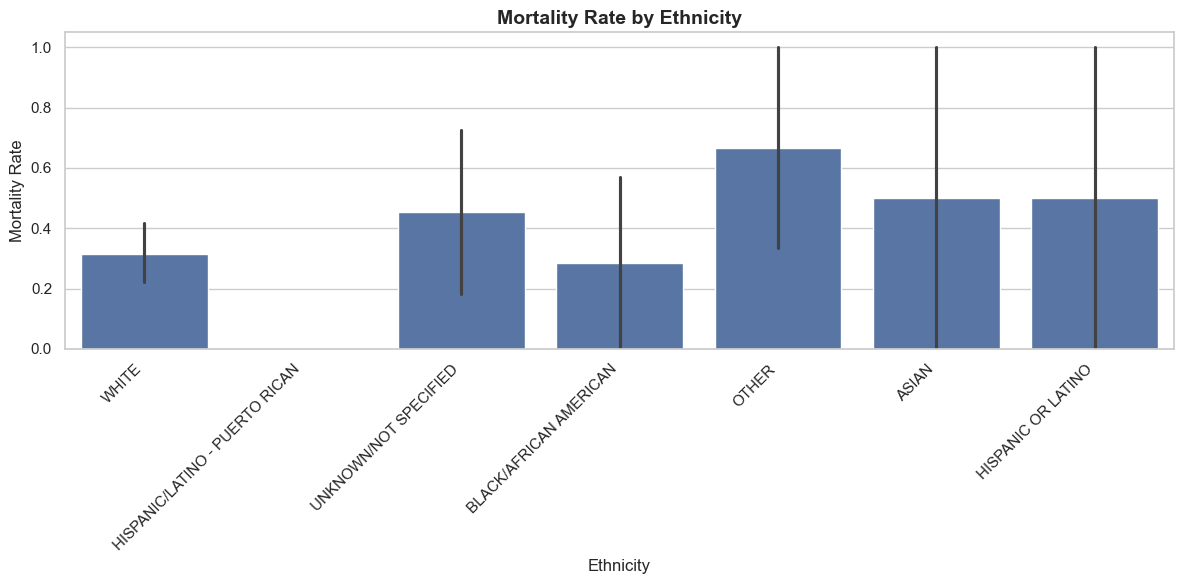

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.



3. TEMPORAL PATTERNS

Admissions by Day of Week:
             hadm_id  hospital_expire_flag
day_of_week                               
Monday            26              0.269231
Tuesday           15              0.200000
Wednesday         18              0.277778
Thursday          24              0.416667
Friday            12              0.500000
Saturday          20              0.250000
Sunday            14              0.285714


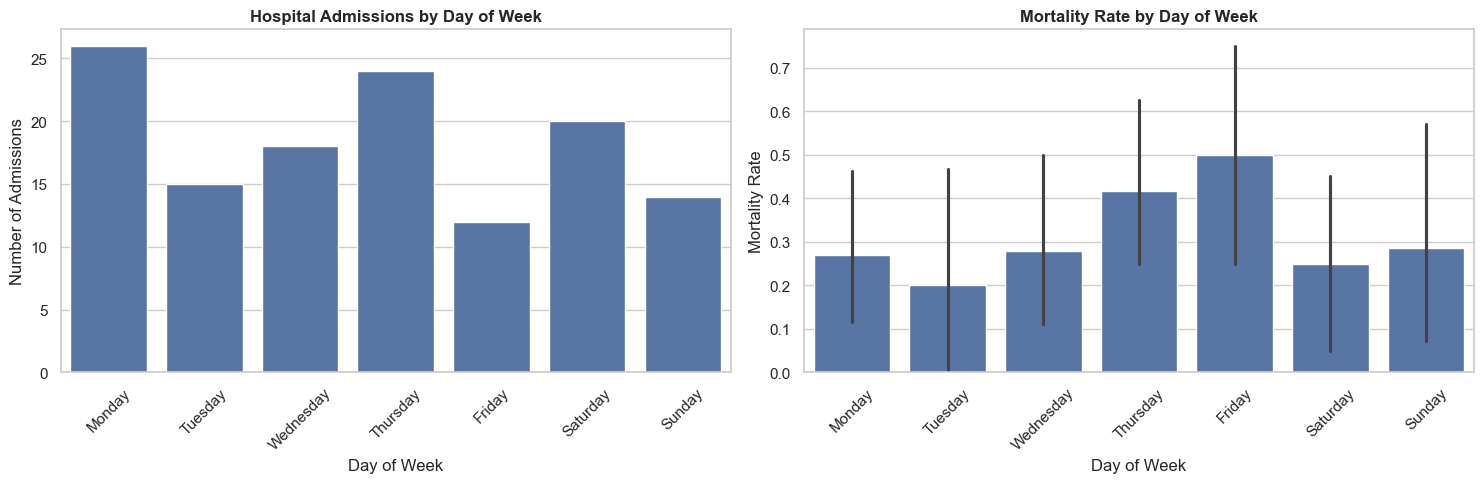

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.



Weekend vs Weekday Mortality:
            hadm_id  hospital_expire_flag
is_weekend                               
Weekday          95              0.326316
Weekend          34              0.264706

4. LENGTH OF STAY ANALYSIS

Hospital Length of Stay Statistics (days):
count    129.000000
mean       9.332332
std       12.720450
min        0.038194
25%        3.314583
50%        6.634028
75%       10.645139
max      123.984722
Name: los_hospital, dtype: float64

LOS by Mortality Status:
                      count      mean        std       min       25%  \
hospital_expire_flag                                                   
0                      89.0  9.766526  13.934030  0.980556  4.104167   
1                      40.0  8.366250   9.569871  0.038194  1.882986   

                           50%        75%         max  
hospital_expire_flag                                   
0                     6.830556  10.146528  123.984722  
1                     4.819444  12.564063   35.2486

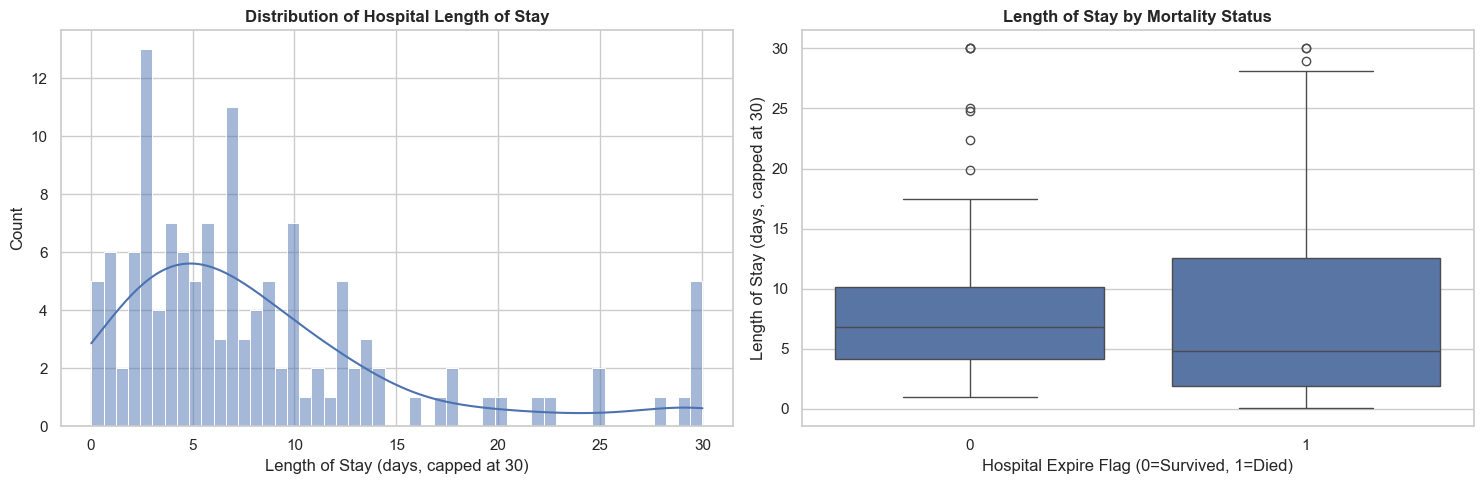


5. READMISSION ANALYSIS

30-Day Readmission Rate: 12.36%

Distribution of Admission Counts:
num_admissions
1     86
2     11
3      2
15     1
Name: count, dtype: int64


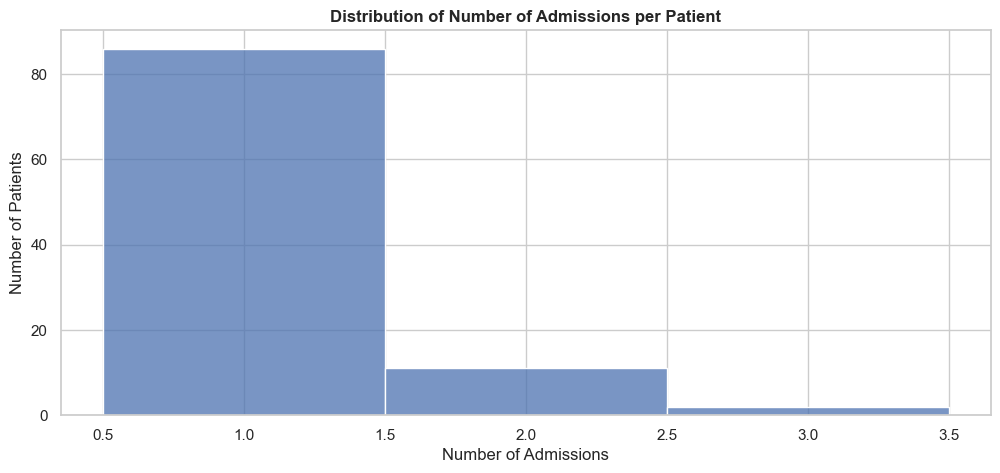


6. TOP DIAGNOSES ANALYSIS

Top 15 Diagnoses (ICD-9 Codes):
icd9_code
4019     53
42731    48
5849     45
4280     39
51881    31
25000    31
2724     29
5990     27
486      26
2859     25
99592    25
0389     24
2449     23
V5861    18
41401    18
Name: count, dtype: int64


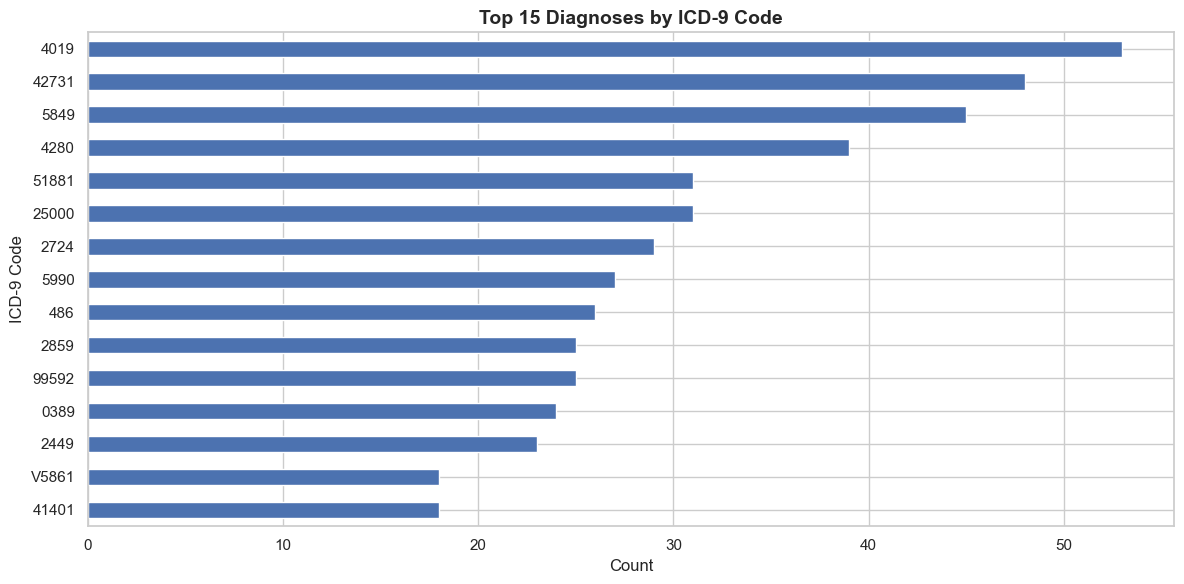


Diagnoses per Admission Statistics:
count    129.000000
mean      13.651163
std        6.465837
min        3.000000
25%        9.000000
50%       12.000000
75%       17.000000
max       37.000000
Name: num_diagnoses, dtype: float64


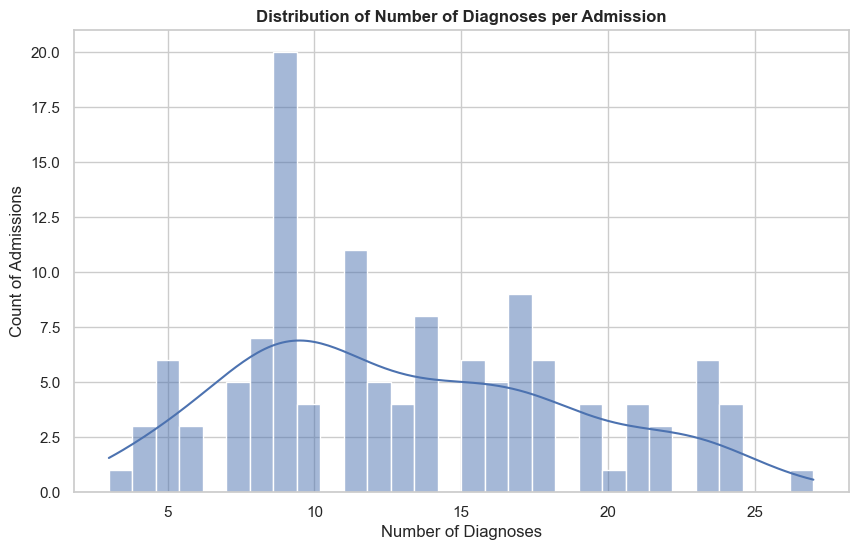


7. ICU ANALYSIS
nkgb
ftgbhr

ICU vs Non-ICU Mortality:
         hadm_id  hospital_expire_flag
had_icu                               
ICU          136              0.338235

ICU vs Non-ICU Mortality:
         hadm_id  hospital_expire_flag
had_icu                               
ICU          136              0.338235

Outcomes by ICU Type:
                hadm_id  hospital_expire_flag       los
first_careunit                                         
MICU                 77              0.324675  3.955345
SICU                 23              0.304348  5.668461
CCU                  19              0.315789  5.753900
TSICU                11              0.636364  3.589609
CSRU                  6              0.166667  3.631350


8. ADMISSION TYPE ANALYSIS

Outcomes by Admission Type:
                hadm_id  hospital_expire_flag  los_hospital
admission_type                                             
EMERGENCY           119              0.327731      9.226932
ELECTIVE              8       

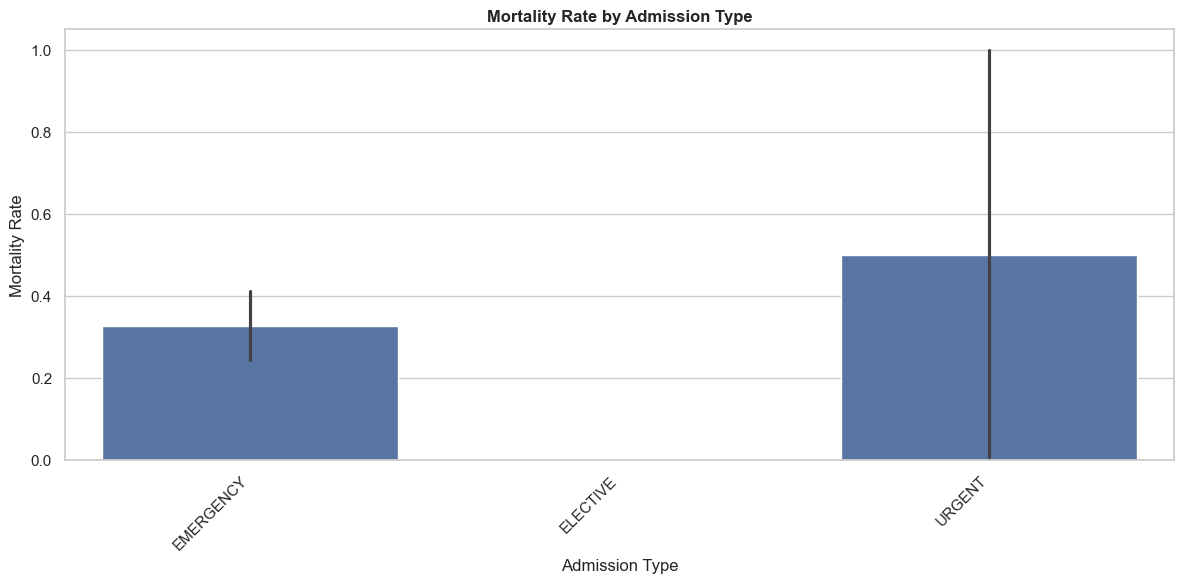


9. AGE AND MORTALITY DETAILED ANALYSIS

Mortality by Age Group:
         hadm_id  hospital_expire_flag  los_hospital
age_bin                                             
0-20           2              0.500000     11.539236
21-30          3              0.666667      1.567593
31-40          1              1.000000     13.852083
41-50         10              0.500000     27.295694
51-60         11              0.090909      9.024179
61-70         29              0.206897      8.315421
71-80         27              0.148148      7.832536
81-90         37              0.432432      8.001258
90+            0                   NaN           NaN


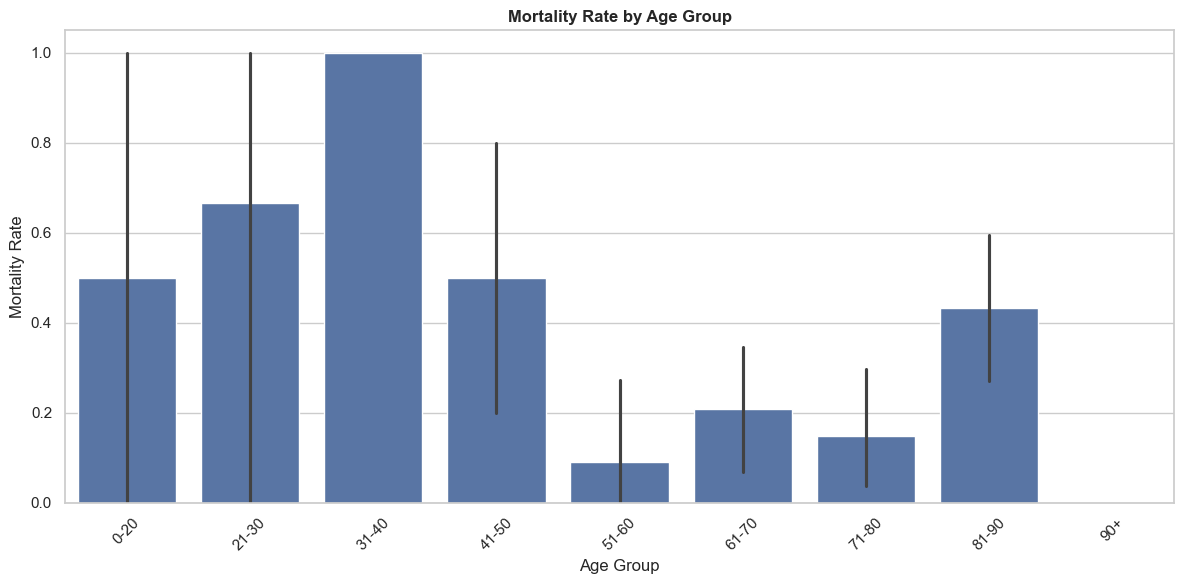


10. COMORBIDITY BURDEN ANALYSIS

Mortality by Number of Diagnoses:
                   hadm_id  hospital_expire_flag
comorbidity_group                               
1-5                     10              0.300000
6-10                    39              0.384615
11-15                   34              0.294118
16-20                   25              0.320000
20+                     21              0.190476


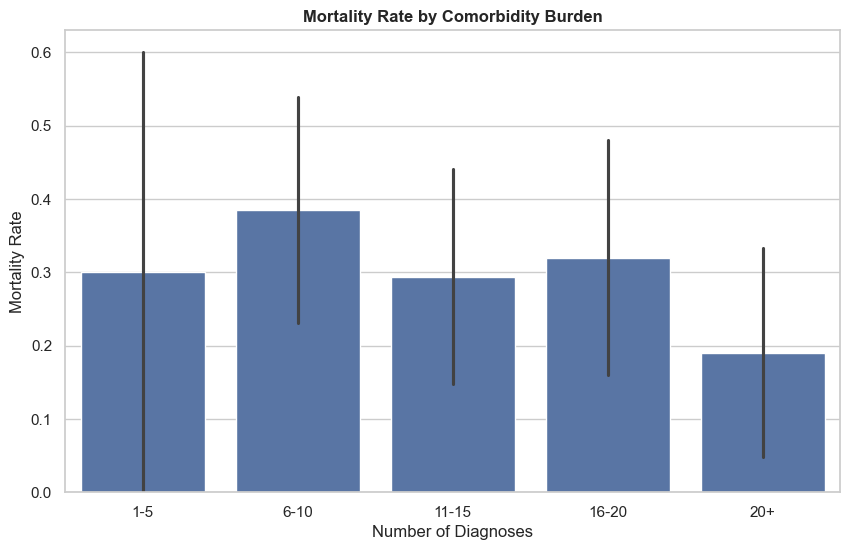


COMPREHENSIVE ANALYSIS COMPLETED!


In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
import logging
from dataclasses import dataclass
from typing import Optional, List

# Configure logging and plotting style
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)


@dataclass
class AgeCalculator:
    """
    Calculate patient age at admission with MIMIC-III specific handling.
    MIMIC-III shifts DOB for patients >89 years (privacy protection).
    """
    patients_df: pd.DataFrame
    admissions_df: pd.DataFrame
    
    def __post_init__(self):
        """Convert DOB and ADMITTIME to datetime objects."""
        self.patients_df['dob'] = pd.to_datetime(self.patients_df['dob'], errors='coerce')
        self.admissions_df['admittime'] = pd.to_datetime(self.admissions_df['admittime'], errors='coerce')
        self.admissions_df['dischtime'] = pd.to_datetime(self.admissions_df['dischtime'], errors='coerce')
        self.admissions_df['deathtime'] = pd.to_datetime(self.admissions_df['deathtime'], errors='coerce')
    
    def calculate_age(self, subject_id: int, hadm_id: int) -> Optional[float]:
        """
        Calculate age at admission for a given subject_id and hadm_id.
        Handles MIMIC-III age > 89 privacy protection.
        """
        try:
            patient_data = self.patients_df[self.patients_df['subject_id'] == subject_id]
            admission_data = self.admissions_df[self.admissions_df['hadm_id'] == hadm_id]
            
            if patient_data.empty or admission_data.empty:
                logger.warning(f"No data found for SUBJECT_ID={subject_id}, HADM_ID={hadm_id}")
                return None
            
            dob = patient_data['dob'].iloc[0]
            admittime = admission_data['admittime'].iloc[0]
            
            if pd.isna(dob) or pd.isna(admittime):
                logger.warning(f"Missing DOB or ADMITTIME for SUBJECT_ID={subject_id}")
                return None
            
            # Calculate age in years
            age_days = (admittime - dob).days
            age = age_days / 365.25
            
            # Handle MIMIC-III shifted DOB (age > 200 indicates privacy protection)
            # Use 91.4 as median for >89 age group per MIMIC-III documentation
            if age > 200:
                logger.debug(f"Age > 200 detected for SUBJECT_ID={subject_id}, setting to 91.4")
                return 91.4
            
            if age < 0:
                logger.warning(f"Negative age for SUBJECT_ID={subject_id}")
                return None
            
            return age
            
        except Exception as e:
            logger.error(f"Error calculating age for SUBJECT_ID={subject_id}: {str(e)}")
            return None
    
    def add_age_to_admissions(self) -> pd.DataFrame:
        """Add age column to admissions dataframe."""
        result = self.admissions_df.copy()
        logger.info("Calculating ages for all admissions...")
        result['age'] = result.apply(
            lambda row: self.calculate_age(row['subject_id'], row['hadm_id']),
            axis=1
        )
        valid_ages = result['age'].notna().sum()
        logger.info(f"Successfully calculated {valid_ages}/{len(result)} ages")
        return result


class MIMICAnalyzer:
    """Comprehensive Exploratory and Statistical Analysis for MIMIC-III dataset."""
    
    def __init__(self, patients, admissions, icustays, diagnoses, procedures, labevents):
        self.icustays = icustays
        self.diagnoses = diagnoses
        self.procedures = procedures
        self.labevents = labevents
        
        # Calculate ages and merge back to dataframes
        age_calc = AgeCalculator(patients.copy(), admissions.copy())
        self.admissions = age_calc.add_age_to_admissions()
        
        # Merge age to patients (first admission age)
        self.patients = patients.copy()
        self.patients = self.patients.merge(
            self.admissions[['subject_id', 'age']].drop_duplicates('subject_id'),
            on='subject_id',
            how='left'
        )
        
        # Calculate mortality and derived features
        self._prepare_data()
    
    def _prepare_data(self):
        """Prepare data with derived features."""
        # Calculate mortality
        if 'hospital_expire_flag' not in self.admissions.columns:
            self.admissions['hospital_expire_flag'] = (
                self.admissions['deathtime'].notna() & 
                (self.admissions['deathtime'] <= self.admissions['dischtime'])
            ).astype(int)
        
        mortality_rate = self.admissions['hospital_expire_flag'].mean() * 100
        logger.info(f"In-hospital Mortality Rate: {mortality_rate:.2f}%")
        
        # Calculate hospital length of stay
        self.admissions['los_hospital'] = (
            self.admissions['dischtime'] - self.admissions['admittime']
        ).dt.total_seconds() / 86400
        
        # Temporal features
        self.admissions['day_of_week'] = self.admissions['admittime'].dt.day_name()
        self.admissions['hour_of_admission'] = self.admissions['admittime'].dt.hour
        self.admissions['is_weekend'] = self.admissions['admittime'].dt.dayofweek.isin([5, 6])
    
    # ============================================================
    # BASIC EDA METHODS
    # ============================================================
    
    def plot_distributions(self, df: pd.DataFrame, columns: List[str], name: str):
        """Plot histogram and boxplot for continuous variables."""
        for col in columns:
            if col not in df.columns:
                logger.warning(f"Column '{col}' not found in {name}")
                continue
            
            if df[col].dtype not in ['float64', 'int64']:
                logger.warning(f"Column '{col}' is not numeric")
                continue
            
            data = df[col].dropna()
            
            if len(data) == 0:
                logger.warning(f"No valid data for '{col}' in {name}")
                continue
            
            fig, axes = plt.subplots(1, 2, figsize=(14, 4))
            
            sns.histplot(data, kde=True, bins=30, ax=axes[0])
            axes[0].set_title(f"Distribution of {col} in {name}")
            axes[0].set_xlabel(col)
            
            sns.boxplot(x=data, ax=axes[1])
            axes[1].set_title(f"Boxplot of {col} in {name}")
            axes[1].set_xlabel(col)
            
            plt.tight_layout()
            plt.show()
    
    def plot_categorical(self, df: pd.DataFrame, column: str, name: str, top_n: int = 10):
        """Plot categorical variable with count plot and pie chart."""
        if column not in df.columns:
            logger.warning(f"Column '{column}' not found in {name}")
            return
        
        valid_data = df[column].dropna()
        
        if len(valid_data) == 0:
            logger.warning(f"No valid data for '{column}' in {name}")
            return
        
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        
        value_counts = valid_data.value_counts()
        top_values = value_counts.index[:top_n]
        sns.countplot(y=valid_data[valid_data.isin(top_values)], 
                     order=top_values, ax=axes[0])
        axes[0].set_title(f"Count of {column} in {name} (Top {top_n})")
        axes[0].set_xlabel("Count")
        
        value_counts.head(5).plot.pie(autopct='%1.1f%%', ax=axes[1])
        axes[1].set_title(f"Distribution of {column} (Top 5)")
        axes[1].set_ylabel('')
        
        plt.tight_layout()
        plt.show()
    
    # ============================================================
    # ADVANCED ANALYSIS METHODS
    # ============================================================
    
    def analyze_gender_mortality(self):
        """1. Gender differences in mortality."""
        print("="*60)
        print("1. GENDER DIFFERENCES IN MORTALITY")
        print("="*60)
        
        gender_mortality = self.admissions.merge(
            self.patients[['subject_id', 'gender']], 
            on='subject_id', 
            how='left'
        )
        
        gender_stats = gender_mortality.groupby('gender')['hospital_expire_flag'].agg([
            ('count', 'count'),
            ('deaths', 'sum'),
            ('mortality_rate', 'mean')
        ])
        print("\nMortality by Gender:")
        print(gender_stats)
        
        plt.figure(figsize=(10, 6))
        sns.barplot(data=gender_mortality, x='gender', y='hospital_expire_flag', ci=95)
        plt.title('Mortality Rate by Gender', fontsize=14, fontweight='bold')
        plt.ylabel('Mortality Rate')
        plt.xlabel('Gender')
        plt.show()
    
    def analyze_ethnicity_outcomes(self):
        """2. Ethnicity and outcomes."""
        print("\n" + "="*60)
        print("2. ETHNICITY AND OUTCOMES")
        print("="*60)
        
        if 'ethnicity' in self.admissions.columns:
            ethnicity_counts = self.admissions['ethnicity'].value_counts()
            top_ethnicities = ethnicity_counts.head(7).index
            self.admissions['ethnicity_grouped'] = self.admissions['ethnicity'].apply(
                lambda x: x if x in top_ethnicities else 'OTHER'
            )
            
            ethnicity_stats = self.admissions.groupby('ethnicity_grouped').agg({
                'hospital_expire_flag': ['count', 'sum', 'mean'],
                'age': 'mean'
            }).round(3)
            print("\nOutcomes by Ethnicity:")
            print(ethnicity_stats)
            
            plt.figure(figsize=(12, 6))
            sns.barplot(data=self.admissions, x='ethnicity_grouped', y='hospital_expire_flag', 
                        order=self.admissions['ethnicity_grouped'].value_counts().index)
            plt.title('Mortality Rate by Ethnicity', fontsize=14, fontweight='bold')
            plt.ylabel('Mortality Rate')
            plt.xlabel('Ethnicity')
            plt.xticks(rotation=45, ha='right')
            plt.tight_layout()
            plt.show()
    
    def analyze_temporal_patterns(self):
        """3. Temporal patterns - day of week and weekend effects."""
        print("\n" + "="*60)
        print("3. TEMPORAL PATTERNS")
        print("="*60)
        
        day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
        dow_stats = self.admissions.groupby('day_of_week').agg({
            'hadm_id': 'count',
            'hospital_expire_flag': 'mean'
        }).reindex(day_order)
        print("\nAdmissions by Day of Week:")
        print(dow_stats)
        
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))
        
        sns.countplot(data=self.admissions, x='day_of_week', order=day_order, ax=axes[0])
        axes[0].set_title('Hospital Admissions by Day of Week', fontweight='bold')
        axes[0].set_xlabel('Day of Week')
        axes[0].set_ylabel('Number of Admissions')
        axes[0].tick_params(axis='x', rotation=45)
        
        sns.barplot(data=self.admissions, x='day_of_week', y='hospital_expire_flag', 
                    order=day_order, ax=axes[1])
        axes[1].set_title('Mortality Rate by Day of Week', fontweight='bold')
        axes[1].set_xlabel('Day of Week')
        axes[1].set_ylabel('Mortality Rate')
        axes[1].tick_params(axis='x', rotation=45)
        
        plt.tight_layout()
        plt.show()
        
        weekend_stats = self.admissions.groupby('is_weekend').agg({
            'hadm_id': 'count',
            'hospital_expire_flag': 'mean'
        })
        
        # Rename index based on what groups actually exist
        index_map = {False: 'Weekday', True: 'Weekend'}
        weekend_stats.index = weekend_stats.index.map(index_map)
        
        print("\nWeekend vs Weekday Mortality:")
        print(weekend_stats)
    
    def analyze_length_of_stay(self):
        """4. Length of stay analysis."""
        print("\n" + "="*60)
        print("4. LENGTH OF STAY ANALYSIS")
        print("="*60)
        
        los_stats = self.admissions['los_hospital'].describe()
        print("\nHospital Length of Stay Statistics (days):")
        print(los_stats)
        
        los_by_mortality = self.admissions.groupby('hospital_expire_flag')['los_hospital'].describe()
        print("\nLOS by Mortality Status:")
        print(los_by_mortality)
        
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))
        
        self.admissions['los_capped'] = self.admissions['los_hospital'].clip(upper=30)
        sns.histplot(data=self.admissions, x='los_capped', bins=50, kde=True, ax=axes[0])
        axes[0].set_title('Distribution of Hospital Length of Stay', fontweight='bold')
        axes[0].set_xlabel('Length of Stay (days, capped at 30)')
        axes[0].set_ylabel('Count')
        
        sns.boxplot(data=self.admissions, x='hospital_expire_flag', y='los_capped', ax=axes[1])
        axes[1].set_title('Length of Stay by Mortality Status', fontweight='bold')
        axes[1].set_xlabel('Hospital Expire Flag (0=Survived, 1=Died)')
        axes[1].set_ylabel('Length of Stay (days, capped at 30)')
        
        plt.tight_layout()
        plt.show()
    
    def analyze_readmissions(self):
        """5. Readmission analysis."""
        print("\n" + "="*60)
        print("5. READMISSION ANALYSIS")
        print("="*60)
        
        admissions_sorted = self.admissions.sort_values(['subject_id', 'admittime'])
        admissions_sorted['next_admittime'] = admissions_sorted.groupby('subject_id')['admittime'].shift(-1)
        admissions_sorted['days_to_readmission'] = (
            admissions_sorted['next_admittime'] - admissions_sorted['dischtime']
        ).dt.total_seconds() / 86400
        
        survived_admissions = admissions_sorted[admissions_sorted['hospital_expire_flag'] == 0].copy()
        survived_admissions['readmitted_30d'] = survived_admissions['days_to_readmission'] <= 30
        
        readmission_rate = survived_admissions['readmitted_30d'].mean() * 100
        print(f"\n30-Day Readmission Rate: {readmission_rate:.2f}%")
        
        admission_counts = self.admissions.groupby('subject_id').size().reset_index(name='num_admissions')
        print("\nDistribution of Admission Counts:")
        print(admission_counts['num_admissions'].value_counts().sort_index().head(10))
        
        plt.figure(figsize=(12, 5))
        sns.histplot(data=admission_counts[admission_counts['num_admissions'] <= 10], 
                     x='num_admissions', bins=10, discrete=True)
        plt.title('Distribution of Number of Admissions per Patient', fontweight='bold')
        plt.xlabel('Number of Admissions')
        plt.ylabel('Number of Patients')
        plt.show()
    
    def analyze_top_diagnoses(self):
        """6. Top diagnoses analysis."""
        print("\n" + "="*60)
        print("6. TOP DIAGNOSES ANALYSIS")
        print("="*60)
        
        top_diagnoses = self.diagnoses['icd9_code'].value_counts().head(15)
        print("\nTop 15 Diagnoses (ICD-9 Codes):")
        print(top_diagnoses)
        
        plt.figure(figsize=(12, 6))
        top_diagnoses.plot(kind='barh')
        plt.title('Top 15 Diagnoses by ICD-9 Code', fontsize=14, fontweight='bold')
        plt.xlabel('Count')
        plt.ylabel('ICD-9 Code')
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()
        
        diag_per_admission = self.diagnoses.groupby('hadm_id').size().reset_index(name='num_diagnoses')
        print("\nDiagnoses per Admission Statistics:")
        print(diag_per_admission['num_diagnoses'].describe())
        
        plt.figure(figsize=(10, 6))
        sns.histplot(data=diag_per_admission[diag_per_admission['num_diagnoses'] <= 30], 
                     x='num_diagnoses', bins=30, kde=True)
        plt.title('Distribution of Number of Diagnoses per Admission', fontweight='bold')
        plt.xlabel('Number of Diagnoses')
        plt.ylabel('Count of Admissions')
        plt.show()
        
        return diag_per_admission
    
    def analyze_icu_outcomes(self):
        """7. ICU analysis."""
        print("\n" + "="*60)
        print("7. ICU ANALYSIS")
        print("="*60)
        
        icu_admissions = self.admissions.merge(
            self.icustays[['hadm_id', 'los', 'first_careunit']], 
            on='hadm_id', 
            how='left'
        )
        print('nkgb')
        icu_admissions['had_icu'] = icu_admissions['los'].notna()
        
        icu_stats = icu_admissions.groupby('had_icu').agg({
            'hadm_id': 'count',
            'hospital_expire_flag': 'mean'
        })
        print('ftgbhr')
        # Rename index based on what groups actually exist
        index_map = {False: 'No ICU', True: 'ICU'}
        icu_stats.index = icu_stats.index.map(index_map)
        
        print("\nICU vs Non-ICU Mortality:")
        print(icu_stats)
        
        print("\nICU vs Non-ICU Mortality:")
        print(icu_stats)
        
        if 'first_careunit' in icu_admissions.columns:
            icu_type_stats = icu_admissions[icu_admissions['had_icu']].groupby('first_careunit').agg({
                'hadm_id': 'count',
                'hospital_expire_flag': 'mean',
                'los': 'mean'
            }).sort_values('hadm_id', ascending=False)
            
            if len(icu_type_stats) > 0:
                print("\nOutcomes by ICU Type:")
                print(icu_type_stats)
        
        # Only plot if we have both groups
        if len(icu_stats) > 1:
            plt.figure(figsize=(10, 6))
            sns.barplot(data=icu_admissions, x='had_icu', y='hospital_expire_flag')
            plt.title('Mortality Rate: ICU vs Non-ICU Admissions', fontweight='bold')
            plt.xlabel('ICU Admission')
            plt.ylabel('Mortality Rate')
            plt.xticks([0, 1], ['No ICU', 'ICU'])
            plt.show()
        else:
            print("\nWarning: Cannot create comparison plot - only one group present")
    
    def analyze_admission_types(self):
        """8. Admission type analysis."""
        print("\n" + "="*60)
        print("8. ADMISSION TYPE ANALYSIS")
        print("="*60)
        
        if 'admission_type' in self.admissions.columns:
            admission_type_stats = self.admissions.groupby('admission_type').agg({
                'hadm_id': 'count',
                'hospital_expire_flag': 'mean',
                'los_hospital': 'mean'
            }).sort_values('hadm_id', ascending=False)
            print("\nOutcomes by Admission Type:")
            print(admission_type_stats)
            
            plt.figure(figsize=(12, 6))
            sns.barplot(data=self.admissions, x='admission_type', y='hospital_expire_flag',
                        order=self.admissions['admission_type'].value_counts().index)
            plt.title('Mortality Rate by Admission Type', fontweight='bold')
            plt.xlabel('Admission Type')
            plt.ylabel('Mortality Rate')
            plt.xticks(rotation=45, ha='right')
            plt.tight_layout()
            plt.show()
    
    def analyze_age_mortality_detailed(self):
        """9. Detailed age and mortality correlation."""
        print("\n" + "="*60)
        print("9. AGE AND MORTALITY DETAILED ANALYSIS")
        print("="*60)
        
        valid_age_admissions = self.admissions[self.admissions['age'].notna()].copy()
        
        valid_age_admissions['age_bin'] = pd.cut(
            valid_age_admissions['age'], 
            bins=[0, 20, 30, 40, 50, 60, 70, 80, 90, 120],
            labels=['0-20', '21-30', '31-40', '41-50', '51-60', '61-70', '71-80', '81-90', '90+']
        )
        
        age_mortality = valid_age_admissions.groupby('age_bin').agg({
            'hadm_id': 'count',
            'hospital_expire_flag': 'mean',
            'los_hospital': 'mean'
        })
        print("\nMortality by Age Group:")
        print(age_mortality)
        
        plt.figure(figsize=(12, 6))
        sns.barplot(data=valid_age_admissions, x='age_bin', y='hospital_expire_flag')
        plt.title('Mortality Rate by Age Group', fontweight='bold')
        plt.xlabel('Age Group')
        plt.ylabel('Mortality Rate')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
    
    def analyze_comorbidity_burden(self, diag_per_admission):
        """10. Comorbidity burden analysis."""
        print("\n" + "="*60)
        print("10. COMORBIDITY BURDEN ANALYSIS")
        print("="*60)
        
        comorbidity_df = self.admissions[['hadm_id', 'hospital_expire_flag']].merge(
            diag_per_admission, on='hadm_id', how='left'
        )
        comorbidity_df['num_diagnoses'] = comorbidity_df['num_diagnoses'].fillna(0)
        
        comorbidity_df['comorbidity_group'] = pd.cut(
            comorbidity_df['num_diagnoses'],
            bins=[0, 5, 10, 15, 20, 100],
            labels=['1-5', '6-10', '11-15', '16-20', '20+']
        )
        
        comorbidity_stats = comorbidity_df.groupby('comorbidity_group').agg({
            'hadm_id': 'count',
            'hospital_expire_flag': 'mean'
        })
        print("\nMortality by Number of Diagnoses:")
        print(comorbidity_stats)
        
        plt.figure(figsize=(10, 6))
        sns.barplot(data=comorbidity_df, x='comorbidity_group', y='hospital_expire_flag')
        plt.title('Mortality Rate by Comorbidity Burden', fontweight='bold')
        plt.xlabel('Number of Diagnoses')
        plt.ylabel('Mortality Rate')
        plt.show()
    
    # ============================================================
    # MAIN EXECUTION METHODS
    # ============================================================
    
    def run_basic_eda(self):
        """Execute basic exploratory data analysis."""
        logger.info("Starting Basic MIMIC-III Exploratory Data Analysis")
        
        logger.info("Analyzing continuous variables...")
        self.plot_distributions(self.patients, ['age'], 'PATIENTS')
        self.plot_distributions(self.icustays, ['los'], 'ICU STAYS')
        
        if len(self.labevents) > 10000:
            labevents_sample = self.labevents.sample(10000, random_state=42)
        else:
            labevents_sample = self.labevents
        
        if 'valuenum' in labevents_sample.columns:
            self.plot_distributions(labevents_sample, ['valuenum'], 'LAB EVENTS (Sample)')
        
        logger.info("Analyzing categorical variables...")
        self.plot_categorical(self.admissions, 'admission_type', 'ADMISSIONS')
        self.plot_categorical(self.patients, 'gender', 'PATIENTS')
        
        if 'ethnicity' in self.admissions.columns:
            self.plot_categorical(self.admissions, 'ethnicity', 'ADMISSIONS')
        elif 'ethnicity' in self.patients.columns:
            self.plot_categorical(self.patients, 'ethnicity', 'PATIENTS')
        
        self.plot_categorical(self.diagnoses, 'icd9_code', 'DIAGNOSES', top_n=15)
        self.plot_categorical(self.procedures, 'icd9_code', 'PROCEDURES', top_n=15)
        
        logger.info("Basic EDA Completed!")
    
    def run_comprehensive_analysis(self):
        """Execute complete comprehensive analysis."""
        logger.info("Starting Comprehensive MIMIC-III Analysis")
        
        self.analyze_gender_mortality()
        self.analyze_ethnicity_outcomes()
        self.analyze_temporal_patterns()
        self.analyze_length_of_stay()
        self.analyze_readmissions()
        diag_per_admission = self.analyze_top_diagnoses()
        self.analyze_icu_outcomes()
        self.analyze_admission_types()
        self.analyze_age_mortality_detailed()
        self.analyze_comorbidity_burden(diag_per_admission)
        
        print("\n" + "="*60)
        print("COMPREHENSIVE ANALYSIS COMPLETED!")
        print("="*60)
    
    def run_all(self):
        """Execute both basic EDA and comprehensive analysis."""
        self.run_basic_eda()
        print("\n" + "="*60)
        print("TRANSITIONING TO COMPREHENSIVE ANALYSIS")
        print("="*60 + "\n")
        self.run_comprehensive_analysis()


# RECREATE the analyzer with the fixed code
analyzer = MIMICAnalyzer(patients, admissions, icustays, diagnoses, procedures, labevents)

# Now run the analysis with the NEW code
analyzer.run_basic_eda()
analyzer.run_comprehensive_analysis()

In [ ]:

def plot_correlation(df, name):
    corr = df.select_dtypes(include=['float64', 'int64']).corr()
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title(f"Correlation Heatmap for {name}")
    plt.show()

plot_correlation(icustays, 'ICUSTAYS')

plot_correlation(labevents_sample, 'LABEVENTS (Sample)')


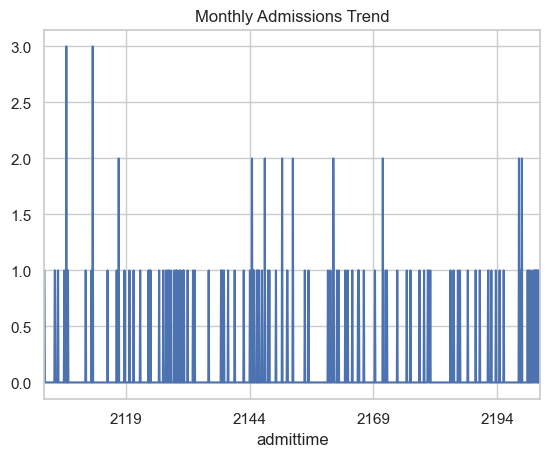

In [9]:
admissions['admittime'] = pd.to_datetime(admissions['admittime'])
admissions.set_index('admittime').resample('M').size().plot()
plt.title('Monthly Admissions Trend')
plt.show()